# NutriMatch — notebook maestro

Proyecto de ciencia de datos para apoyar la decisión de compra de alimentos empacados en México.

El hilo del cuaderno es este:

```text
datos → exploración → hallazgos → decisiones → preparación → variables → motor → evaluación → conclusiones
```

Cada sección plantea una pregunta, mide el corte oficial y deja una decisión. El motor de decisión es determinista. NutriMatch no utiliza aprendizaje supervisado porque el catálogo no contiene un target observado que permita entrenar y evaluar de manera científicamente válida un modelo de recomendación.

**Corte oficial.** `datos/procesados/dataset_referencia_20261002.parquet`, 2 de octubre de 2026.

**Corte histórico, solo como contexto.** El 19 de septiembre de 2026 el universo de México en Open Food Facts tenía 16 851 productos. El análisis de ese corte estimó 5 856 productos con núcleo, categoría y NOVA (34,8 %) y una correlación de Spearman de −0,4747 entre la dimensión nutricional y Nutri-Score (n = 6 041). Esas cifras no se recalculan aquí y no describen el sistema actual.


## 0. Contexto y objetivo

### Pregunta

¿Qué decisión apoya NutriMatch y con qué información?

### Respuesta

Una persona frente al anaquel encuentra productos parecidos cuya información nutricional, de procesamiento, de etiquetas, de alérgenos y de precio está dispersa y no siempre está completa. NutriMatch ordena alternativas según las prioridades, la dieta y las alergias que esa persona declara.

El usuario es quien compra alimentos empacados y puede decir qué quiere privilegiar: nutrición, grado de procesamiento o etiquetas como orgánico o sin gluten. También puede declarar una dieta vegana o vegetariana y alérgenos que necesita evitar.

La decisión que el sistema prepara es cuál de los productos comparables encaja mejor con ese perfil, y cuándo la información no alcanza para ordenarlos. La persona agrega, sustituye o descarta. El sistema no determina que un alimento sea saludable para toda la población y no emite un diagnóstico.

La ciencia de datos entra en cuatro lugares: describir la disponibilidad real del catálogo, decidir qué ausencias se conservan, construir variables comparables dentro de una categoría y evaluar el motor sin inventar un desenlace de compra.


## 1. Preparación del ambiente

El cuaderno usa Python, pandas, matplotlib y el paquete `nutrimatch` del repositorio. No instala bibliotecas de modelado. La correlación de Spearman se calcula con rangos de pandas, como en `evaluacion/parity_check.py`, sin añadir SciPy.

El Parquet operativo pesa unos 9 MB y está versionado. No hace falta el export CSV de Open Food Facts ni los cortes de septiembre.

La primera celda de código deja el entorno listo.

En esta máquina, si el directorio de trabajo es la raíz del proyecto o `notebooks/`, esa celda solo confirma la raíz. No reinstala el paquete.

En Google Colab no hay un repositorio remoto que clonar. Hay que subir `nutrimatch-colab.zip` a `/content`, con ese nombre, y ejecutar el cuaderno de arriba abajo. La celda descomprime el archivo en `/content/nutrimatch`, comprueba que estén el Parquet, el paquete y `evaluacion`, instala el proyecto y se sitúa en esa raíz. Python tiene que ser 3.11 o posterior. Si al importar aparece `ModuleNotFoundError`, se reinicia el entorno y se vuelve a ejecutar desde esa celda. El Parquet no se cambia.

La celda siguiente localiza la misma raíz, agrega el paquete al camino de importación y carga las funciones del motor. No usa rutas de una máquina concreta.


In [ ]:
# Prepara el entorno antes de leer datos.
# En local solo confirma la raíz del proyecto y no reinstala el paquete.
# En Google Colab descomprime nutrimatch-colab.zip, ya subido a /content,
# se sitúa en esa carpeta e instala el paquete. No descarga otro corte ni abre una conexión a una API.

import os
import sys
import zipfile
from pathlib import Path

NOMBRE_PARQUET = "dataset_referencia_20261002.parquet"
ZIP_COLAB = Path("/content/nutrimatch-colab.zip")
DESTINO_COLAB = Path("/content/nutrimatch")


def es_colab() -> bool:
    # La variable existe en Colab antes de importar librerías del proyecto.
    return os.environ.get("COLAB_RELEASE_TAG") is not None


def raiz_valida(ruta: Path) -> bool:
    return all(
        (
            (ruta / "datos" / "procesados" / NOMBRE_PARQUET).is_file(),
            (ruta / "src" / "nutrimatch").is_dir(),
            (ruta / "evaluacion").is_dir(),
            (ruta / "pyproject.toml").is_file(),
        )
    )


def buscar_raiz():
    actual = Path.cwd().resolve()
    candidatos = [actual, *actual.parents]
    if DESTINO_COLAB.is_dir():
        candidatos.append(DESTINO_COLAB)
    for candidato in candidatos:
        if raiz_valida(candidato):
            return candidato
    return None


raiz = buscar_raiz()
if raiz is None and es_colab() and ZIP_COLAB.is_file():
    # La raíz del ZIP ya es la raíz del proyecto.
    DESTINO_COLAB.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_COLAB) as archivo:
        archivo.extractall(DESTINO_COLAB)
    if raiz_valida(DESTINO_COLAB):
        raiz = DESTINO_COLAB

if raiz is None and es_colab():
    raise FileNotFoundError(
        "Sube nutrimatch-colab.zip a /content, con ese nombre, y vuelve a ejecutar esta celda."
    )
if raiz is None:
    raise FileNotFoundError(
        "No está la raíz del proyecto. Hacen falta el Parquet oficial, src/nutrimatch, evaluacion y pyproject.toml."
    )

os.chdir(raiz)

if es_colab():
    # Instala nutrimatch y las librerías que el cuaderno importa. No añade librerías de modelado.
    import subprocess

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--disable-pip-version-check",
            "--root-user-action=ignore",
            "-e",
            str(raiz),
        ]
    )
    print("Colab: paquete instalado.")
else:
    print("Entorno local: no se reinstala el paquete.")

print("RAIZ_OK", raiz)


In [1]:
# Localiza la raíz del proyecto, fija el corte oficial y carga las funciones del motor.
# No recalcula las fórmulas: las importa del paquete.

import os
import sys
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

def encontrar_raiz() -> Path:
    # Busca hacia arriba desde el directorio de trabajo y, en Colab, en /content/nutrimatch.
    nombre = "dataset_referencia_20261002.parquet"
    candidatos = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    colab = Path("/content/nutrimatch")
    if colab.is_dir():
        candidatos.append(colab)
    for candidato in candidatos:
        parquet = candidato / "datos" / "procesados" / nombre
        paquete = candidato / "src" / "nutrimatch"
        if parquet.is_file() and paquete.is_dir():
            return candidato
    raise FileNotFoundError(
        "No está la raíz del proyecto. En Colab, sube nutrimatch-colab.zip a /content "
        "y vuelve a ejecutar desde la celda de preparación."
    )

RAIZ = encontrar_raiz()
os.chdir(RAIZ)
for ruta in (RAIZ / "src", RAIZ):
    texto = str(ruta)
    if texto not in sys.path:
        sys.path.insert(0, texto)

RUTA_DATASET = RAIZ / "datos" / "procesados" / "dataset_referencia_20261002.parquet"
SHA_ESPERADO = "a621d471a2f47aa09ba481408d95a7a808fe84bd2fa7205c56fa050e1c66045b"
CORTE = "2026-10-02"
DATASET_ID = "dataset_referencia_20261002"

from evaluacion.golden_set import CASOS, evaluar
from evaluacion.parity_check import UMBRAL_CORRELACION_RAZONABLE, calcular_parity_check
from nutrimatch.engine.constants import CORE8_NUTRIENTES, MINIMO_PEERS_PERCENTIL, TAMANO_MINIMO_CATEGORIA
from nutrimatch.engine.coverage import UMBRAL_COV_INFORMACION_INSUFICIENTE
from nutrimatch.engine.nutrition_score import NUTRIENTES_D1_SIGNO, calcular_subpuntaje_d1
from nutrimatch.engine.user_weights import convertir_prioridades_a_pesos
from nutrimatch.schemas.profile import UserProfile
from nutrimatch.services.catalog import Catalog
from nutrimatch.services.ranking import _item_desde_fila

plt.rcParams.update({
    "figure.figsize": (8, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 11,
})

print("Raíz:", RAIZ)
print("Dataset:", RUTA_DATASET.name)
print("Umbral de categoría:", TAMANO_MINIMO_CATEGORIA)
print("Mínimo de pares por percentil:", MINIMO_PEERS_PERCENTIL)
print("Umbral de cobertura:", UMBRAL_COV_INFORMACION_INSUFICIENTE)


Raíz: /Users/paola_cov/Documents/NutriMatch
Dataset: dataset_referencia_20261002.parquet
Umbral de categoría: 30
Mínimo de pares por percentil: 5
Umbral de cobertura: 0.5


## 2. Carga y descripción de los datos

### Pregunta

¿Cuál es la unidad de análisis y qué contiene el corte oficial?

### Análisis


In [2]:
# Abre solo el Parquet del 2 de octubre de 2026.
# Si la huella no coincide, la celda se detiene y no se analiza otro archivo.
# Al cargar el catálogo se calcula D1 en memoria. Esa columna no está guardada en el Parquet.

huella = hashlib.sha256(RUTA_DATASET.read_bytes()).hexdigest()
print("SHA-256:", huella)
if huella != SHA_ESPERADO:
    raise RuntimeError("La huella del Parquet no es la del corte oficial. No se continúa con otro archivo.")

crudo = pd.read_parquet(RUTA_DATASET)
crudo["code"] = crudo["code"].astype(str)
catalogo = Catalog.from_referencia_frame(crudo, snapshot_id="off_csv_20260929")
df = catalogo.df

print("Filas y columnas del Parquet:", crudo.shape)
print("Columnas en memoria después de calcular D1:", df.shape[1])
print("Códigos duplicados:", int(df["code"].duplicated().sum()))
print("Memoria del frame cargado, MB:", round(df.memory_usage(deep=True).sum() / 1e6, 1))
print("Tipos:")
print(df.dtypes.astype(str).value_counts().to_string())
print()
columnas_ficha = [
    "code",
    "product_name",
    "categoria_referencia",
    "d2",
    "universo_puntuable",
    "price_status",
    "data_quality_level",
]
display(df[columnas_ficha].head(5))


SHA-256: a621d471a2f47aa09ba481408d95a7a808fe84bd2fa7205c56fa050e1c66045b


Filas y columnas del Parquet: (13093, 273)
Columnas en memoria después de calcular D1: 274
Códigos duplicados: 0
Memoria del frame cargado, MB: 76.0
Tipos:
str        202
Int32       27
float64     27
bool        13
Float64      3
Int64        1
int64        1



,code,product_name,categoria_referencia,d2,universo_puntuable,price_status,data_quality_level
0,7503001908113,fibritas,NaN,22.222222,False,UNAVAILABLE,media
1,7503002028162,Banderillas Corn Dog Jumbo,en:meals,0.000000,True,UNAVAILABLE,alta
2,7503002147122,Tostada Marisquera,NaN,NaN,False,UNAVAILABLE,insuficiente
3,7503002167823,Wolter Chocolate oscuro Wolter Chocolate Oscuro,NaN,NaN,False,UNAVAILABLE,baja
4,7503002193693,Nopal con chile y limón,NaN,NaN,False,UNAVAILABLE,insuficiente


### Hallazgo

El archivo del corte `dataset_referencia_20261002` tiene 13 093 productos y 273 columnas. Al cargarlo, el catálogo calcula D1 y el frame en memoria queda con 274 columnas. Esa columna no está guardada en el Parquet. La huella coincide con el metadato del archivo. Hay 0 códigos duplicados.

### Decisión

La unidad de análisis es el producto identificado por su código. No se agrupan presentaciones que comparten nombre. No se eliminan filas por tener campos vacíos: un ausente se conserva y más adelante decide si el producto puede ordenarse.


## 3. Exploración y calidad de los datos

La exploración responde qué se puede comparar con la información que realmente llegó al catálogo. Las cifras de esta sección salen del corte del 2 de octubre de 2026.


### 3.1 Cobertura de variables

#### Pregunta

¿De qué dimensiones hay dato suficiente para comparar productos?


,grupo,con_dato,pct
0,Categoría de referencia,7568,57.80
1,Al menos 4 percentiles del núcleo,6998,53.45
2,"D2, procesamiento",6780,51.78
3,Etiquetas,3776,28.84
4,Alérgenos,2790,21.31
5,Trazas,1990,15.20
6,Precio de mercado,259,1.98
7,Nombre visible,12712,97.09
8,Marca,11606,88.64


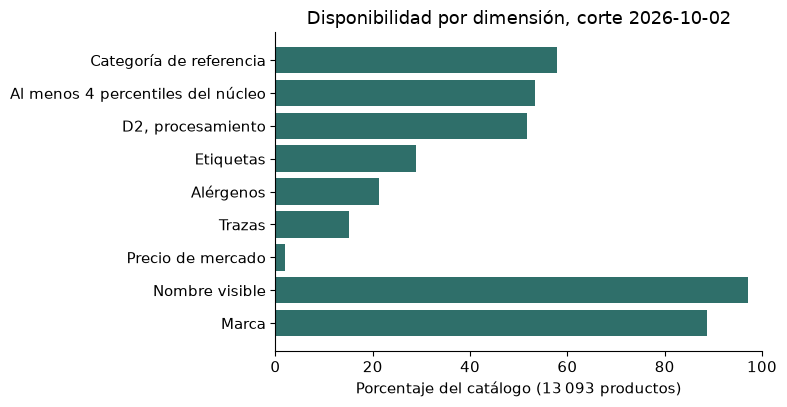

In [3]:
# Mide qué fracción del catálogo trae cada dimensión.
# Un texto vacío, o la cadena «nan», cuenta como ausente.

def porcentaje(n, total=len(df)):
    return round(100 * n / total, 2)

def con_dato(serie):
    texto = serie.astype("string").str.strip()
    return int((serie.notna() & texto.ne("") & texto.str.lower().ne("nan") & texto.str.lower().ne("<na>")).sum())

grupos = pd.DataFrame([
    ("Categoría de referencia", int(df["categoria_referencia"].notna().sum())),
    ("Al menos 4 percentiles del núcleo", int((df["n_percentiles_validos"] >= 4).sum())),
    ("D2, procesamiento", int(df["d2"].notna().sum())),
    ("Etiquetas", con_dato(df["labels_tags"])),
    ("Alérgenos", con_dato(df["allergens"])),
    ("Trazas", con_dato(df["traces"])),
    ("Precio de mercado", int((df["price_status"] == "REAL").sum())),
    ("Nombre visible", int(df["product_name_homologated"].notna().sum())),
    ("Marca", int((df["brand_status"] == "DERIVED").sum())),
], columns=["grupo", "con_dato"])
grupos["pct"] = grupos["con_dato"].map(porcentaje)
display(grupos)

fig, ax = plt.subplots()
ax.barh(grupos["grupo"][::-1], grupos["pct"][::-1], color="#2f6f6a")
ax.set_xlabel("Porcentaje del catálogo (13 093 productos)")
ax.set_xlim(0, 100)
ax.set_title("Disponibilidad por dimensión, corte 2026-10-02")
plt.tight_layout()
plt.show()


#### Hallazgo

Ninguna dimensión cubre el catálogo entero. El precio de mercado es la más escasa. Categoría, percentiles y procesamiento cubren cerca de la mitad. El nombre visible existe para casi todos los productos; la marca, no.

#### Decisión

El motor trabaja con las dimensiones que sí tienen dato. No se completa el catálogo para que todas las filas entren a un mismo cálculo.


### 3.2 Datos faltantes

#### Pregunta

¿La ausencia de un campo puede leerse como un cero o como la ausencia del atributo?


In [4]:
# Cuenta datos ausentes. Un precio nulo no es un precio de cero pesos.
# El percentil puede faltar aunque el valor saneado del nutriente sí exista.

def vacio(col):
    texto = df[col].astype("string").str.strip()
    return df[col].isna() | texto.eq("") | texto.str.lower().eq("nan") | texto.str.lower().eq("<na>")

faltantes = pd.DataFrame([
    ("Azúcares, valor saneado", int(df["sugars_100g_saneado"].isna().sum())),
    ("Azúcares, percentil", int(df["percentil_sugars_100g"].isna().sum())),
    ("Sal, valor saneado", int(df["salt_100g_saneado"].isna().sum())),
    ("Grasa saturada, valor saneado", int(df["saturated-fat_100g_saneado"].isna().sum())),
    ("Fibra, valor saneado", int(df["fiber_100g_saneado"].isna().sum())),
    ("Proteína, valor saneado", int(df["proteins_100g_saneado"].isna().sum())),
    ("NOVA", int(df["nova_group"].isna().sum())),
    ("Etiquetas", int(vacio("labels_tags").sum())),
    ("Alérgenos y trazas, ambos vacíos", int((vacio("allergens") & vacio("traces")).sum())),
    ("Precio nulo", int(df["price"].isna().sum())),
    ("Precio igual a cero", int((df["price"] == 0).sum())),
], columns=["campo", "filas"])
faltantes["pct"] = faltantes["filas"].map(porcentaje)
display(faltantes)


,campo,filas,pct
0,"Azúcares, valor saneado",2605,19.90
1,"Azúcares, percentil",6360,48.58
2,"Sal, valor saneado",2902,22.16
3,"Grasa saturada, valor saneado",2657,20.29
4,"Fibra, valor saneado",2834,21.65
5,"Proteína, valor saneado",1139,8.70
6,NOVA,6313,48.22
7,Etiquetas,9317,71.16
8,"Alérgenos y trazas, ambos vacíos",9611,73.41
9,Precio nulo,12834,98.02


#### Hallazgo

Hay miles de nutrientes, grupos NOVA, etiquetas y alérgenos vacíos. Los 12 834 precios ausentes están guardados como nulo: 0 filas tienen precio igual a cero. Un nutriente puede existir saneado y, aun así, no tener percentil, porque el percentil pide una categoría de referencia y al menos cinco productos con dato en esa categoría.

#### Decisión

La ausencia de información no se interpreta como ausencia del atributo.

- Un alérgeno ausente no significa «sin ese alérgeno».
- Una etiqueta ausente no significa «no cumple la preferencia».
- Un precio ausente no es un precio de cero pesos.
- Un nutriente ausente no entra al promedio como el mejor ni como el peor valor.

Esas reglas ya están en el motor. Esta sección solo muestra que el corte les da motivo.


### 3.3 Calidad de información

#### Pregunta

¿La calidad del registro debe cambiar el orden de los productos?


,productos
data_quality_level,
alta,6102
media,1511
baja,1274
insuficiente,4206


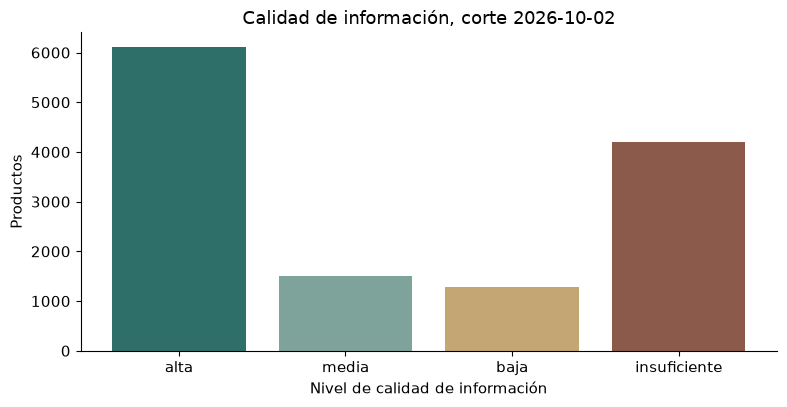

Suma: 13093 de 13093


In [5]:
# La calidad de información resume disponibilidad y coherencia del registro.
# Si el conteo no es el del corte oficial, la celda se detiene.

orden_calidad = ["alta", "media", "baja", "insuficiente"]
calidad = df["data_quality_level"].value_counts().reindex(orden_calidad)
esperado = {"alta": 6102, "media": 1511, "baja": 1274, "insuficiente": 4206}
for nivel, n in esperado.items():
    if int(calidad.loc[nivel]) != n:
        raise RuntimeError(f"Calidad {nivel}: el corte trae {int(calidad.loc[nivel])}, la cifra congelada es {n}.")
display(calidad.to_frame("productos"))

fig, ax = plt.subplots()
ax.bar(calidad.index, calidad.values, color=["#2f6f6a", "#7ea39a", "#c4a574", "#8c5a4a"])
ax.set_ylabel("Productos")
ax.set_xlabel("Nivel de calidad de información")
ax.set_title("Calidad de información, corte 2026-10-02")
plt.tight_layout()
plt.show()
print("Suma:", int(calidad.sum()), "de", len(df))


#### Hallazgo

En el corte del 2 de octubre de 2026 hay 6 102 productos de calidad alta, 1 511 de calidad media, 1 274 de calidad baja y 4 206 de calidad insuficiente.

#### Decisión

`data_quality_score` resume disponibilidad y coherencia física. Informa la ficha. No es una dimensión del score y no reordena el ranking. Más adelante, con un perfil de ejemplo, se verá que productos de calidad alta pueden quedar excluidos por dieta o alergia.


### 3.4 Categorías

#### Pregunta

¿Se pueden comparar los nutrientes de dos productos sin un grupo de referencia?


Productos sin categoría de referencia: 5525
Categorías de referencia distintas: 201
Etiquetas elegidas que aparecen en menos de 30 productos: 0
Mediana de productos que comparten la misma categoría de referencia: 27.0
Categorías de referencia con menos de 30 productos asignados: 107

Nivel de retroceso (0 = se usó la etiqueta más específica):
nivel_retroceso
0       4138
1       1877
2        775
3        361
4        199
5         97
6         48
7         30
8         12
9         12
10         6
11         5
12         5
13         1
14         1
21         1
<NA>    5525


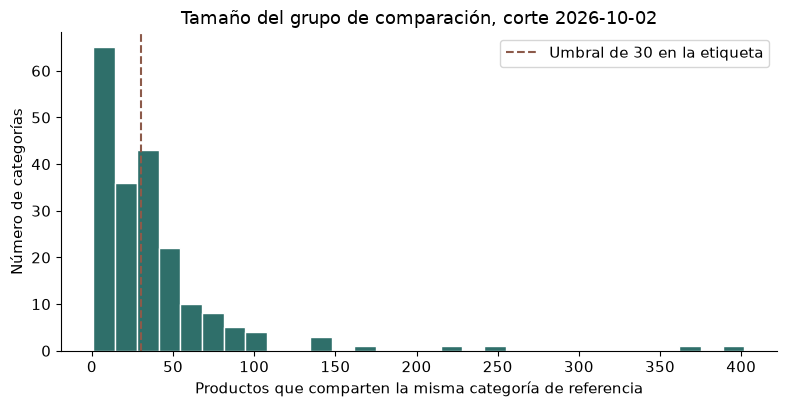

In [6]:
# Revisa el grupo con el que se comparan los nutrientes.
# El umbral de 30 productos sale del motor. No se propone otra taxonomía.

def tamanos_de_etiqueta(serie):
    conteo = {}
    for tags in serie.dropna():
        for etiqueta in {t.strip() for t in str(tags).split(",") if t.strip()}:
            conteo[etiqueta] = conteo.get(etiqueta, 0) + 1
    return conteo

tamanos = tamanos_de_etiqueta(df["categories_tags"])
elegidas = df.loc[df["categoria_referencia"].notna(), "categoria_referencia"].unique()
bajo_umbral = [etiqueta for etiqueta in elegidas if tamanos.get(etiqueta, 0) < TAMANO_MINIMO_CATEGORIA]
asignados = df["categoria_referencia"].value_counts(dropna=True)

print("Productos sin categoría de referencia:", int(df["categoria_referencia"].isna().sum()))
print("Categorías de referencia distintas:", asignados.size)
print("Etiquetas elegidas que aparecen en menos de", TAMANO_MINIMO_CATEGORIA, "productos:", len(bajo_umbral))
print("Mediana de productos que comparten la misma categoría de referencia:", float(asignados.median()))
print("Categorías de referencia con menos de 30 productos asignados:", int((asignados < 30).sum()))
print()
print("Nivel de retroceso (0 = se usó la etiqueta más específica):")
print(df["nivel_retroceso"].value_counts(dropna=False).sort_index().to_string())

fig, ax = plt.subplots()
ax.hist(asignados, bins=30, color="#2f6f6a", edgecolor="white")
ax.axvline(TAMANO_MINIMO_CATEGORIA, color="#8c5a4a", linestyle="--", label="Umbral de 30 en la etiqueta")
ax.set_xlabel("Productos que comparten la misma categoría de referencia")
ax.set_ylabel("Número de categorías")
ax.set_title("Tamaño del grupo de comparación, corte 2026-10-02")
ax.legend()
plt.tight_layout()
plt.show()


#### Hallazgo

5 525 productos no tienen categoría de referencia: ninguna etiqueta de su jerarquía alcanza 30 productos. Las 201 etiquetas que sí fueron elegidas aparecen, cada una, en al menos 30 productos del catálogo. El grupo que termina compartiendo la misma `categoria_referencia` es más chico, porque otros productos con esa etiqueta resolvieron a una etiqueta más específica. La mediana de ese grupo es 27 productos, y 107 categorías de referencia agrupan a menos de 30.

4 138 productos usaron su etiqueta más específica. 1 877 subieron un nivel. El resto subió más, hasta 21 niveles en un caso.

#### Decisión

La comparación nutricional es relativa a productos comparables. La categoría de referencia sale de `categories_tags`, de lo específico a lo genérico, y se detiene en la primera etiqueta que alcanzan al menos 30 productos. Si la jerarquía se agota, D1 queda sin dato. Además, el percentil de un nutriente pide al menos cinco pares con ese dato. No se inventa otra taxonomía.


### 3.5 Nutrición

#### Pregunta

¿Qué nutrientes tienen una dirección clara para ordenar productos dentro de su categoría?


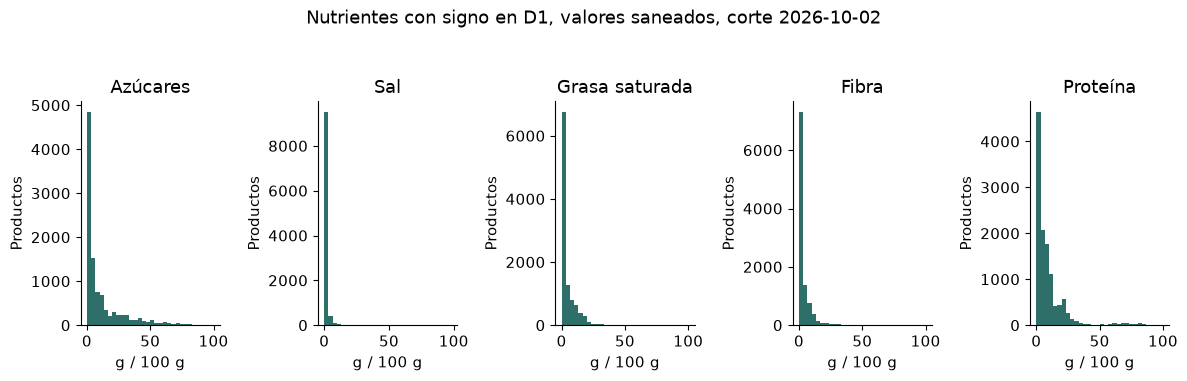

,nutriente,saneados,con_percentil,signo
0,Azúcares,10488,6733,menos es mejor
1,Sal,10191,6727,menos es mejor
2,Grasa saturada,10436,6679,menos es mejor
3,Fibra,10259,6544,más es mejor
4,Proteína,11954,6942,más es mejor


D1 calculable en la carga del catálogo: 7028


In [7]:
# Muestra los cinco nutrientes que entran a D1 y la dirección de cada uno.
# Energía, grasa total y carbohidratos quedan fuera: no tienen un signo único.

nutrientes = [
    ("sugars_100g_saneado", "Azúcares"),
    ("salt_100g_saneado", "Sal"),
    ("saturated-fat_100g_saneado", "Grasa saturada"),
    ("fiber_100g_saneado", "Fibra"),
    ("proteins_100g_saneado", "Proteína"),
]
fig, ejes = plt.subplots(1, 5, figsize=(12, 3.6))
for ax, (columna, titulo) in zip(ejes, nutrientes, strict=True):
    serie = df[columna].dropna()
    ax.hist(serie, bins=30, color="#2f6f6a")
    ax.set_title(titulo)
    ax.set_xlabel("g / 100 g")
    ax.set_ylabel("Productos")
fig.suptitle("Nutrientes con signo en D1, valores saneados, corte 2026-10-02", y=1.05)
plt.tight_layout()
plt.show()

resumen_nut = []
for columna, titulo in nutrientes:
    percentil = "percentil_" + columna.replace("_saneado", "")
    resumen_nut.append({
        "nutriente": titulo,
        "saneados": int(df[columna].notna().sum()),
        "con_percentil": int(df[percentil].notna().sum()),
        "signo": "menos es mejor" if NUTRIENTES_D1_SIGNO[columna.replace("_saneado", "")] < 0 else "más es mejor",
    })
display(pd.DataFrame(resumen_nut))
print("D1 calculable en la carga del catálogo:", int(df["d1"].notna().sum()))


#### Hallazgo

Azúcares, sal, grasa saturada, fibra y proteína tienen valores saneados para una mayoría del catálogo, con distribuciones concentradas en valores bajos y una cola larga. El percentil existe en menos filas que el valor saneado. D1 queda calculable en 7 028 de 13 093 productos.

Energía, grasa total y carbohidratos también tienen percentil en el archivo. No tienen un signo único para cualquier persona: según la meta, más energía puede ser deseable o no. Por eso no entran a D1.

#### Decisión

D1 promedia, entre los cinco nutrientes que sí tienen percentil, una contribución con signo: azúcares, sal y grasa saturada hacia abajo; fibra y proteína hacia arriba. El nutriente sin percentil no entra a ese promedio.


### 3.6 Procesamiento

#### Pregunta

¿El grupo NOVA, por sí solo, separa el catálogo?


,productos
nova_group,
1,804
2,189
3,1078
4,4709
sin NOVA,6313


Con D2: 6780
Sin NOVA: 6313
Sin número de aditivos: 5444


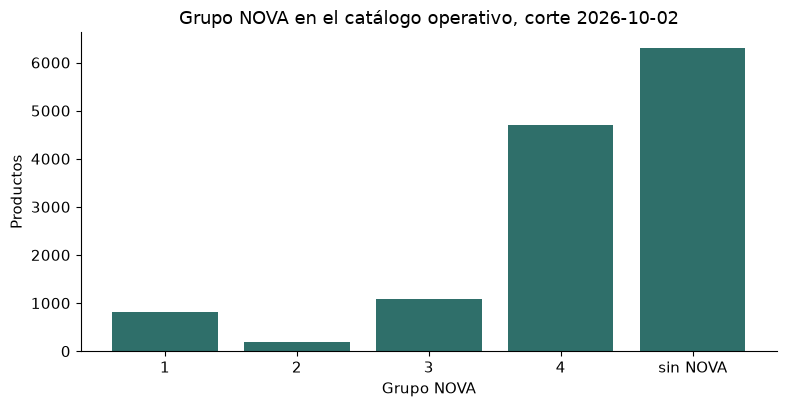

In [8]:
# Describe el grupo NOVA. Sin grupo, D2 queda nulo.
# Esta celda no imputa el grupo ni vuelve a calcular el subpuntaje.

nova = df["nova_group"].astype("string").str.strip()
conteo_nova = nova.fillna("sin NOVA").value_counts()
orden_nova = ["1", "2", "3", "4", "sin NOVA"]
conteo_nova = conteo_nova.reindex(orden_nova)
display(conteo_nova.to_frame("productos"))
print("Con D2:", int(df["d2"].notna().sum()))
print("Sin NOVA:", int(nova.isna().sum()))
print("Sin número de aditivos:", int(df["additives_n"].isna().sum()))

fig, ax = plt.subplots()
ax.bar(conteo_nova.index.astype(str), conteo_nova.values, color="#2f6f6a")
ax.set_xlabel("Grupo NOVA")
ax.set_ylabel("Productos")
ax.set_title("Grupo NOVA en el catálogo operativo, corte 2026-10-02")
plt.tight_layout()
plt.show()


#### Hallazgo

6 313 productos no tienen grupo NOVA y tampoco tienen D2. De los 6 780 que sí tienen grupo, 4 709 están en el grupo 4. El número de aditivos falta en 5 444 productos.

#### Decisión

Sin NOVA, D2 queda nulo. No se imputa el grupo. Cada grupo ocupa una banda de 25 puntos: el grupo 1 entre 75 y 100, el 4 entre 0 y 25. Los aditivos empujan el subpuntaje hacia el piso de la banda. Si el número de aditivos falta, el ajuste es neutro y el producto queda al centro de su banda. D2 ya está materializado en el Parquet; el cuaderno no vuelve a calcularlo.


### 3.7 Etiquetas y preferencias

#### Pregunta

¿Se puede puntuar una preferencia cuando el producto no declara etiquetas?


In [9]:
# Calcula D3 para un perfil que valora orgánico y sin gluten.
# Nulo: no hay etiquetas que leer. Cero: hay etiquetas y ninguna es de las valoradas.

from nutrimatch.engine.preference_score import calcular_d3

etiquetas_ejemplo = ["en:organic", "en:no-gluten"]
d3_ejemplo = df["labels_tags"].map(lambda valor: calcular_d3(valor, etiquetas_ejemplo))
resumen_d3 = pd.DataFrame({
    "situacion": ["D3 nulo", "D3 igual a 0", "D3 mayor que 0"],
    "productos": [
        int(d3_ejemplo.isna().sum()),
        int((d3_ejemplo == 0).sum()),
        int((d3_ejemplo > 0).sum()),
    ],
})
display(resumen_d3)
print("Etiquetas vacías:", int(vacio("labels_tags").sum()))


,situacion,productos
0,D3 nulo,9317
1,D3 igual a 0,3068
2,D3 mayor que 0,708


Etiquetas vacías: 9317


#### Hallazgo

Para una persona que valora orgánico y sin gluten, D3 es nulo en 9 317 productos: no hay etiquetas que leer. D3 es 0 en 3 068: el producto sí declara etiquetas y ninguna es de las dos valoradas. D3 es mayor que 0 en 708.

#### Decisión

D3 es el porcentaje de etiquetas valoradas que el producto presenta. Si la persona no eligió etiquetas, o el producto no trae ninguna, D3 es nulo. El cero solo aparece cuando hay etiquetas observadas y ninguna coincide. Una etiqueta ausente no se convierte en preferencia negativa ni en preferencia positiva.


### 3.8 Precios

#### Pregunta

¿El precio puede entrar al orden de compatibilidad?


,productos
price_status,
UNAVAILABLE,12834
REAL,259


Imputados: 0
Sintéticos en el Parquet: 0
Reales por fuente:
price_source
open_prices    239
qqp_profeco     20


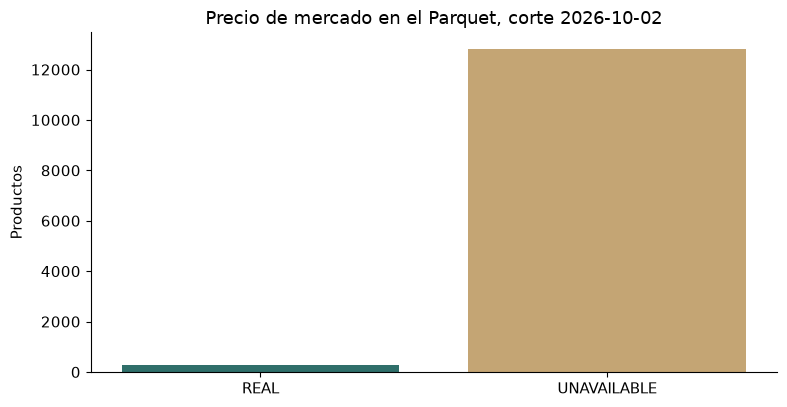

In [10]:
# Separa el precio observado del precio ausente.
# En este Parquet no debe haber precios imputados ni sintéticos.

precios = df["price_status"].value_counts()
display(precios.to_frame("productos"))
print("Imputados:", int((df["price_status"] == "IMPUTED").sum()))
print("Sintéticos en el Parquet:", int((df["price_status"] == "SYNTHETIC").sum()))
print("Reales por fuente:")
print(df.loc[df["price_status"] == "REAL", "price_source"].value_counts().to_string())

fig, ax = plt.subplots()
ax.bar(["REAL", "UNAVAILABLE"], [int(precios.get("REAL", 0)), int(precios.get("UNAVAILABLE", 0))], color=["#2f6f6a", "#c4a574"])
ax.set_ylabel("Productos")
ax.set_title("Precio de mercado en el Parquet, corte 2026-10-02")
plt.tight_layout()
plt.show()


#### Hallazgo

Hay 259 precios `REAL`: 239 de Open Prices por código de barras y 20 de PROFECO por texto revisado. Hay 12 834 precios `UNAVAILABLE`. En el Parquet hay 0 precios `IMPUTED` y 0 precios `SYNTHETIC`.

#### Decisión

El precio no se imputa y no entra a D1, D2 ni D3. Cuando la ficha responde por un producto sin precio observado, puede mostrar un monto de demostración marcado como tal. Ese monto no está en este dataset y no participa en el ranking.


## 4. Hallazgos y decisiones

Las decisiones de abajo ya están en el motor. La evidencia es del corte del 2 de octubre de 2026, salvo la fila histórica, que queda separada.

| Hallazgo | Evidencia en el corte 2026-10-02 | Decisión |
| --- | --- | --- |
| El precio de mercado cubre una fracción pequeña del catálogo | 259 reales y 12 834 nulos; 0 precios en cero | No imputar un precio. El ranking no lo usa |
| Alérgenos y trazas faltan juntos en la mayoría de los productos | 9 611 filas con ambos campos vacíos | Si la persona declara un alérgeno y no hay dato, el estado es no verificable |
| Las etiquetas faltan en 9 317 productos | D3 nulo en esas filas; D3 = 0 solo si hay etiquetas y ninguna coincide | No convertir la ausencia en 0 ni en 100 |
| La jerarquía de categorías está fragmentada | 5 525 productos sin categoría de referencia; las 201 etiquetas elegidas sí alcanzan 30 productos | Comparar dentro de `categoria_referencia`. Si la jerarquía se agota, D1 queda sin dato |
| Tener el nutriente no alcanza para compararlo | Azúcares saneados en 10 488 filas y con percentil en 6 733 | El percentil pide categoría y al menos 5 pares. El nutriente sin percentil no entra a D1 |
| NOVA no separa el catálogo en cuatro grupos parejos | 6 313 sin NOVA; 4 709 de 6 780 con NOVA están en el grupo 4 | D2 es nulo sin NOVA. Dentro del grupo, los aditivos ajustan la banda |
| La calidad de información está desbalanceada | 6 102 alta, 1 511 media, 1 274 baja, 4 206 insuficiente | La calidad informa. No es un peso del score |
| Hay errores físicos localizados | 56 banderas de sal fuera de rango y 55 correcciones de escala | Corregir la sal solo con el sodio del mismo producto cuando la razón es aproximadamente 2,5. El resto no entra al percentil |
| El código no se repite | 0 duplicados en 13 093 filas | La unidad sigue siendo el código. No se agrupan nombres |

**Corte histórico, 19 de septiembre de 2026.** Sobre 16 851 productos, el análisis previo estimó 5 856 con núcleo, categoría y NOVA, y un Spearman de −0,4747 (n = 6 041). Ese universo y esa definición no son los del archivo operativo. El catálogo actual tiene 13 093 productos porque la ingesta aplicó tres candados —no alimento, integridad mínima e identidad de nombre— sobre el mismo export. El metadato del Parquet oficial guarda ese recorrido.


## 5. Preparación y limpieza

### Pregunta

¿Qué tratamiento recibió el dato antes de construir las variables del motor?

### Análisis

La limpieza ya está aplicada en el Parquet. Esta sección cuenta sus rastros. No crea una segunda versión del archivo.


In [11]:
# Lee las banderas de la limpieza que ya está aplicada en el Parquet.
# No reescribe el archivo ni completa los huecos.

banderas = [
    "salt_100g_flag_fuera_de_rango",
    "salt_100g_flag_correccion_escala_aplicada",
    "flag_suma_macros_excede_100",
]
for columna in banderas:
    print(columna, int(df[columna].fillna(False).astype(bool).sum()))

fuera = df["salt_100g_flag_fuera_de_rango"].fillna(False).astype(bool)
corregida = df["salt_100g_flag_correccion_escala_aplicada"].fillna(False).astype(bool)
print("Correcciones que también están marcadas fuera de rango:", int((fuera & corregida).sum()))
print("Fuera de rango sin corrección:", int((fuera & ~corregida).sum()))
print("Nombres DERIVED / REAL / UNAVAILABLE:")
print(df["product_name_status"].value_counts(dropna=False).to_string())
print("Precios nulos con estado UNAVAILABLE:", int(((df["price"].isna()) & (df["price_status"] == "UNAVAILABLE")).sum()))


salt_100g_flag_fuera_de_rango 56
salt_100g_flag_correccion_escala_aplicada 55
flag_suma_macros_excede_100 57
Correcciones que también están marcadas fuera de rango: 55
Fuera de rango sin corrección: 1
Nombres DERIVED / REAL / UNAVAILABLE:
product_name_status
DERIVED        12707
UNAVAILABLE      381
REAL               5
Precios nulos con estado UNAVAILABLE: 12834


### Hallazgo

55 productos tienen la corrección de escala de la sal, y los 55 están entre las 56 banderas de sal fuera de rango. Un producto queda fuera de rango sin corrección. 57 productos tienen la suma de macronutrientes por encima de 100 g; esa bandera informa y no borra los nutrientes. El nombre visible es `DERIVED` en 12 707 filas, `REAL` en 5 y `UNAVAILABLE` en 381. Los 12 834 precios ausentes siguen nulos.

### Decisión

NULL no significa cero. La información faltante se conserva cuando no hay evidencia para imputarla. Un valor fuera de rango físico deja de aportar al percentil y el dato crudo sigue en la ficha. La sal se reescala solo cuando su razón con el sodio del mismo producto es aproximadamente 2,5 y el valor dividido entre 1 000 cae en un rango válido. Los estados del archivo son `REAL`, `DERIVED` y `UNAVAILABLE`. `IMPUTED` y `SYNTHETIC` no aparecen en este Parquet.


## 6. Ingeniería de variables

### Pregunta

¿Qué variables usa el motor y cuáles solo informan?

| Variable | Tipo | Origen | Uso |
| --- | --- | --- | --- |
| `code` | Original | Open Food Facts | Identificador del producto |
| Nutrientes `*_100g` | Original | Open Food Facts | Insumo del saneamiento |
| `*_100g_saneado` y banderas de rango | Derivada | Rango físico y, en la sal, el sodio del mismo producto | Base del percentil. El crudo sigue visible |
| `categoria_referencia` | Derivada | `categories_tags`, retroceso hasta 30 productos | Grupo de comparación de D1 |
| `percentil_*` de azúcares, sal, grasa saturada, fibra y proteína | Derivada | Valor saneado dentro de la categoría, mínimo 5 pares | D1, con signo |
| Percentiles de energía, grasa total y carbohidratos | Derivada | La misma regla | Solo ficha. No entran a D1 |
| `d2` | Derivada, ya en el Parquet | Grupo NOVA y número de aditivos | Procesamiento |
| D3 | Calculada en la consulta | `labels_tags` y etiquetas que la persona valora | Preferencias |
| Pesos 3/6, 2/6 y 1/6 | Regla fija | Orden de tres prioridades | Ponderación |
| `score` | Calculado en la consulta | D1, D2 y D3 disponibles | Orden dentro de la banda de ranking |
| `universo_puntuable` | Derivada | Al menos 4 de 8 percentiles y D2 presente | Disponibilidad metodológica, previa al perfil |
| `data_quality_score` y `data_quality_level` | Derivada | Disponibilidad y coherencia | Diagnóstico. No entra al score |
| `price` con `price_status` | Observación de otra fuente | Open Prices o PROFECO, o ausencia | Ficha. No entra al score |

El precio de demostración que puede mostrar la ficha no es una variable de este archivo.

D1 se calcula al cargar el catálogo, con `calcular_subpuntaje_d1`, a partir de los percentiles. D2 se lee del Parquet. D3, los pesos, la cobertura, la banda y el score se calculan cuando llega un perfil.


## 7. Universo puntuable

### Pregunta

¿Qué productos tienen suficiente información nutricional y de procesamiento para ser comparables, antes de conocer a la persona?

Un producto pertenece al universo puntuable si tiene D2 y al menos 4 de los 8 percentiles del núcleo. Es una condición de disponibilidad. No es una predicción de preferencia ni la lista que verá una persona.


Universo puntuable: 5864 de 13093
Porcentaje: 44.79
Filas en las que la bandera no coincide con la regla: 0


,productos
Catálogo,13093
Con categoría de referencia,7568
Con al menos 4 percentiles,6998
Con D2,6780
Universo puntuable,5864


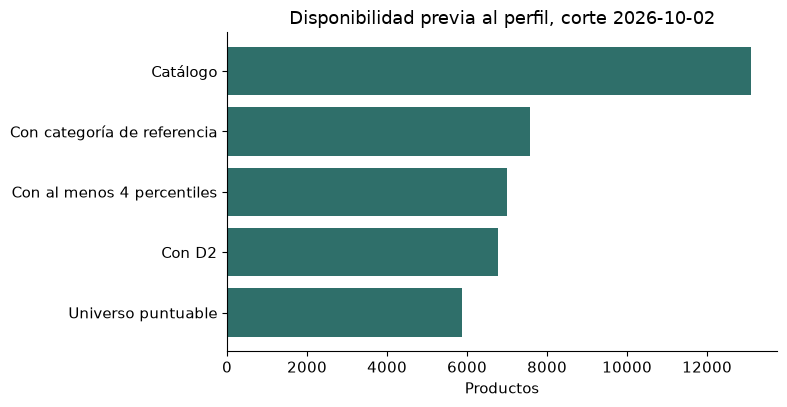

In [12]:
# Universo puntuable: hay D2 y al menos cuatro de ocho percentiles del núcleo.
# Es una condición de disponibilidad, previa al perfil. No es una lista de recomendados.
# Si la bandera del archivo no coincide con la regla, la celda se detiene.

regla = df["d2"].notna() & (df["n_percentiles_validos"] >= 4)
bandera = df["universo_puntuable"].fillna(False).astype(bool)
desajuste = int((bandera != regla).sum())
n_puntuable = int(bandera.sum())
print("Universo puntuable:", n_puntuable, "de", len(df))
print("Porcentaje:", round(100 * n_puntuable / len(df), 2))
print("Filas en las que la bandera no coincide con la regla:", desajuste)
if n_puntuable != 5864 or desajuste != 0 or len(df) != 13093:
    raise RuntimeError("El universo puntuable de este archivo no coincide con la cifra congelada. Revisar el corte antes de citarlo.")

conjuntos = pd.Series({
    "Catálogo": len(df),
    "Con categoría de referencia": int(df["categoria_referencia"].notna().sum()),
    "Con al menos 4 percentiles": int((df["n_percentiles_validos"] >= 4).sum()),
    "Con D2": int(df["d2"].notna().sum()),
    "Universo puntuable": n_puntuable,
})
display(conjuntos.to_frame("productos"))

fig, ax = plt.subplots()
ax.barh(conjuntos.index[::-1], conjuntos.values[::-1], color="#2f6f6a")
ax.set_xlabel("Productos")
ax.set_title("Disponibilidad previa al perfil, corte 2026-10-02")
plt.tight_layout()
plt.show()


### Hallazgo

5 864 de 13 093 productos (44,79 %) están en el universo puntuable. La bandera del archivo coincide con la regla en las 13 093 filas.

Los conjuntos de la gráfica no forman una cascada anidada. Tener categoría, tener cuatro percentiles y tener D2 son condiciones distintas. El universo puntuable es la intersección de D2 y al menos cuatro percentiles.

### Decisión

Un producto fuera de ese universo sigue en el catálogo y puede consultarse. Según el perfil, todavía puede recibir score si la cobertura de las dimensiones presentes llega al umbral. Puntuable, existente y recomendado siguen siendo tres conjuntos distintos.


## 8. Motor de decisión

### Pregunta

¿Cómo se convierte un perfil en un orden de productos?

El motor usa tres subpuntajes.

**D1, nutrición.** Promedio de las contribuciones disponibles entre cinco nutrientes. Azúcares, sal y grasa saturada restan respecto del percentil alto. Fibra y proteína suman el percentil. Si ninguno de los cinco tiene percentil, D1 es nulo.

**D2, procesamiento.** Valor ya guardado en el Parquet. Sin NOVA, es nulo.

**D3, etiquetas.** Porcentaje de las etiquetas valoradas que el producto presenta. Sin etiquetas valoradas o sin etiquetas en el producto, es nulo.

**Pesos.** La persona ordena las tres dimensiones. La primera recibe 3 puntos, la segunda 2 y la tercera 1. Al dividir entre 6 quedan 0,50, 0,33 y 0,17. La celda imprime los pesos exactos de la función `convertir_prioridades_a_pesos`.

**Score.** Suma de subpuntaje por peso, entre las dimensiones con dato, dividida entre la suma de esos pesos. La dimensión ausente no se sustituye por cero. Si la cobertura es menor que 0,5, el score es nulo.

**Bandas.** Cada producto cae en una sola, en este orden:

1. Excluido, si la alergia es no apta o la dieta es incompatible.
2. No verificable, si la alergia o la dieta no tienen evidencia suficiente.
3. Información insuficiente, si la cobertura es menor que 0,5.
4. Ranking, el resto, de mayor score a menor.

El perfil de las celdas siguientes es un perfil de ejemplo, el mismo que usó el análisis del 20 de septiembre de 2026 para probar la sensibilidad. No es una usuaria observada. Declara alergia al gluten, dieta vegana, las etiquetas orgánico y sin gluten, y el orden nutrición, etiquetas, procesamiento.


In [13]:
# Aplica el motor a un perfil de ejemplo. No entrena un modelo.
# El perfil declara gluten, dieta vegana y las etiquetas orgánico y sin gluten, con nutrición primero.
# La dimensión ausente no entra como cero.

def evaluar_perfil(frame, perfil):
    pesos = convertir_prioridades_a_pesos(list(perfil.priority_order))
    columnas = list(frame.columns)
    filas = []
    for tupla in frame.itertuples(index=False, name=None):
        serie = pd.Series(dict(zip(columnas, tupla, strict=True)))
        item, _banda = _item_desde_fila(serie, perfil, pesos, con_explicacion=False)
        filas.append({
            "code": item.code,
            "name": item.product_name,
            "category": item.category,
            "d1": item.d1,
            "d2": item.d2,
            "d3": item.d3,
            "score": item.score,
            "cov": item.cov,
            "band": item.band,
            "allergy": item.allergy_status,
            "diet": item.diet_status,
        })
    return pd.DataFrame(filas), pesos

perfil_nutricion = UserProfile(
    allergen_tags=["en:gluten"],
    diet="vegano",
    valued_labels=["en:organic", "en:no-gluten"],
    priority_order=["D1", "D3", "D2"],
)
resultado, pesos = evaluar_perfil(df, perfil_nutricion)
print("Pesos con nutrición primero:", {k: round(v, 4) for k, v in pesos.items()})
print(resultado["band"].value_counts().to_string())

codigo_ejemplo = "7501030457626"
fila = df.loc[df["code"] == codigo_ejemplo].iloc[0]
percentiles = {
    nutriente: None if pd.isna(fila.get(f"percentil_{nutriente}")) else float(fila.get(f"percentil_{nutriente}"))
    for nutriente in CORE8_NUTRIENTES
}
d1_ejemplo, detalle = calcular_subpuntaje_d1(percentiles)
print()
print("Ejemplo", codigo_ejemplo, fila["product_name"])
print("D1 recalculado:", None if d1_ejemplo is None else round(d1_ejemplo, 4), "D2 en el archivo:", fila["d2"])
display(pd.DataFrame(detalle).T)


Pesos con nutrición primero: {'D1': 0.5, 'D3': 0.3333, 'D2': 0.1667}
band
no_verificable              9171
excluido                    3808
ranking                      113
informacion_insuficiente       1

Ejemplo 7501030457626 Pan con Centeno
D1 recalculado: 52.2072 D2 en el archivo: 13.88888888888889


,percentil,signo,disponible,contribucion
sugars_100g,44.303797,-1,True,55.696203
salt_100g,72.5,-1,True,27.5
saturated-fat_100g,60.759494,-1,True,39.240506
fiber_100g,58.139535,1,True,58.139535
proteins_100g,80.45977,1,True,80.45977


### Hallazgo

Con nutrición primero, los pesos exactos son 0,50 para D1, 0,3333 para D3 y 0,1667 para D2. En este perfil, 3 808 productos quedan excluidos, 9 171 no verificables, 1 con información insuficiente y 113 en la banda de ranking.

El ejemplo `7501030457626` conserva el D1 y el D2 usados como regresión del caso de oro. El detalle por nutriente muestra cuáles aportan y cuáles no tienen percentil.

### Decisión

El orden lo produce esta regla, con el perfil declarado. No hay un modelo entrenado entre el dato y el score.


## 9. Evaluación

Las cifras de esta sección son del corte del 2 de octubre de 2026. Nutri-Score se usa como contraste externo. No es variable objetivo, no es ground truth y no es una etiqueta de entrenamiento.

### 9.1 Cobertura del universo puntuable

5 864 de 13 093 productos (44,79 %) cumplen la condición de disponibilidad definida en la sección 7. Eso mide cuántos productos traen D2 y al menos cuatro percentiles. No mide cuántos recomienda un perfil. En el perfil de ejemplo, la banda de ranking tiene 113 productos.


### 9.2 Casos de oro

Trece productos reales, con un comportamiento esperado escrito antes de esta corrida. El verificador es `evaluacion/golden_set.py`. No se modifican las expectativas. La columna que el verificador llama nombre bruto es `product_name` del archivo operativo.


In [14]:
# Contrasta trece casos revisados a mano. Las expectativas no se modifican aquí.
# Un caso puede diferir en el nombre resuelto y conservar el mismo score.

evaluacion_oro = df.copy()
evaluacion_oro["product_name_bruto"] = evaluacion_oro["product_name"]
reporte_oro = evaluar(evaluacion_oro)
print("Casos:", len(reporte_oro), "pasan:", int(reporte_oro["paso"].sum()))
display(reporte_oro[["code", "paso", "descripcion"]])
fallidos = reporte_oro.loc[~reporte_oro["paso"]]
for fila in fallidos.itertuples():
    print("No pasa", fila.code)
    print(fila.fallos)
    original = df.loc[df["code"] == fila.code].iloc[0]
    print("product_name:", original["product_name"])
    print("product_name_original:", original["product_name_original"])
    print("product_name_field_source:", original["product_name_field_source"])
    print("product_name_flag_respaldo_usado:", original["product_name_flag_respaldo_usado"])


Casos: 13 pasan: 12


,code,paso,descripcion
0,7501000112425,True,Donitas espolvoreadas: azúcar/sal/grasa satura...
1,7501030473022,True,TOSTIS CON FIBRA: azúcar/sal/grasa saturada en...
2,0000654193184,True,Milton's Galletas Saladas Multigrano: allergen...
3,0010248765159,True,Fideo mediano: gluten SOLO en traces ('puede c...
4,00000140,True,tisane saveur lunaire: allergens y traces ambo...
5,0000880688789,True,Mister Natural - Datil Premium: ingredients_an...
6,0000182602460,True,Isabar: ingredients_analysis_tags trae 'en:non...
7,0010248765135,True,Yemina Semilla de melón: ingredients_analysis_...
8,00000154,True,Mct Oil Powder: sin categoria_referencia resol...
9,0000880688787,True,Mister Natural - Chabacano Deshidratado: tiene...


No pasa 5060323907641
['se_uso_respaldo esperado True (viene de generic_name)']
product_name: Organic Smooth Almond Butter
product_name_original: nan
product_name_field_source: generic_name
product_name_flag_respaldo_usado: True


#### Hallazgo

Los 13 códigos están en el operativo. 12 cumplen la expectativa. `5060323907641` no la cumple cuando el verificador lee `product_name`: esa columna ya contiene «Organic Smooth Almond Butter», así que la función de nombres no marca un respaldo. `product_name_original` sigue vacío, la fuente del nombre visible es `generic_name` y la bandera de respaldo del archivo está en verdadero.

#### Decisión de lectura

El fallo no significa que el producto haya desaparecido ni que D1 o D2 estén mal. Es una diferencia de contrato entre el nombre crudo que esperaba el caso y el nombre ya resuelto en el corte oficial. El caso se conserva.


### 9.3 Contraste con Nutri-Score

#### Pregunta

¿El orden de D1 va, en conjunto, en sentido contrario al de Nutri-Score?

D1 alto es más favorable en NutriMatch. `nutriscore_score` alto es menos favorable en Nutri-Score. Por eso el signo esperado de Spearman es negativo. El umbral de sanidad del proyecto es −0,3. No se interpreta como exactitud.


nutriscore_score no nulos: 6423 convertidos a número: 6423
n: 6035
Spearman: -0.475683
Umbral: -0.3 se cumple: True
El promedio de D1 no sube de «a» a «e»: True


,d1_promedio
nutriscore_grade,
a,59.68
b,54.80
c,50.87
d,49.00
e,41.57


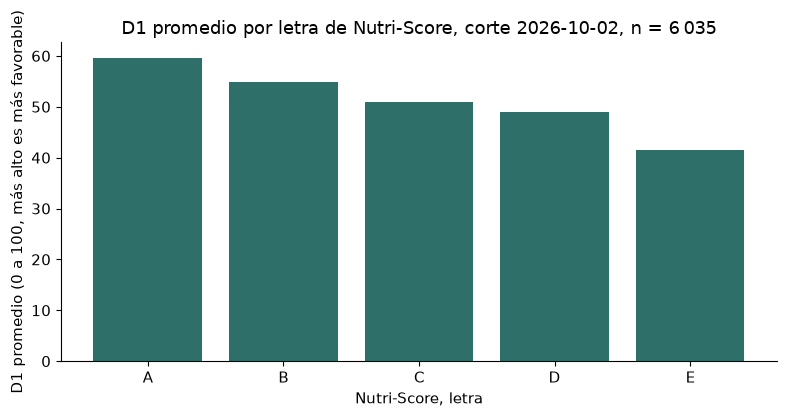

In [15]:
# Contrasta la dirección de D1 con Nutri-Score. Nutri-Score no es la respuesta correcta del sistema.
# D1 alto es más favorable aquí. El score de Nutri-Score alto es menos favorable.
# Por eso se espera una correlación negativa. Si n o Spearman no coinciden, la celda se detiene.

score_nutri = pd.to_numeric(df["nutriscore_score"], errors="coerce")
print("nutriscore_score no nulos:", int(df["nutriscore_score"].notna().sum()), "convertidos a número:", int(score_nutri.notna().sum()))
parity = calcular_parity_check(df["d1"], score_nutri, df["nutriscore_grade"])
print("n:", parity["n"])
print("Spearman:", round(parity["correlacion_spearman"], 6))
print("Umbral:", UMBRAL_CORRELACION_RAZONABLE, "se cumple:", parity["correlacion_razonable"])
print("El promedio de D1 no sube de «a» a «e»:", parity["monotono_por_grado"])
promedios = parity["promedio_d1_por_grado"].round(2)
display(promedios.to_frame("d1_promedio"))

if parity["n"] != 6035 or round(parity["correlacion_spearman"], 6) != -0.475683:
    raise RuntimeError(
        "Spearman o su n no coinciden con la cifra congelada. "
        f"Obtenido n={parity['n']}, rho={parity['correlacion_spearman']}. No se sustituye el resultado."
    )

fig, ax = plt.subplots()
ax.bar(promedios.index.str.upper(), promedios.values, color="#2f6f6a")
ax.set_xlabel("Nutri-Score, letra")
ax.set_ylabel("D1 promedio (0 a 100, más alto es más favorable)")
ax.set_title("D1 promedio por letra de Nutri-Score, corte 2026-10-02, n = 6 035")
plt.tight_layout()
plt.show()


#### Hallazgo

En los 6 035 productos con D1 y `nutriscore_score`, Spearman es −0,475683. El umbral −0,3 se cumple. El promedio de D1 decrece de la letra A a la E: 59,68, 54,80, 50,87, 49,00 y 41,57.

El Spearman del 19 de septiembre fue −0,4747 sobre 6 041 productos de otro archivo. No es el resultado de este corte.

#### Decisión

El contraste se conserva como chequeo de dirección. No se entrena nada para acercar D1 a Nutri-Score.


### 9.4 Determinismo

#### Pregunta

¿La misma entrada produce la misma salida?


In [16]:
# Repite el mismo perfil y comprueba que el score, la banda y el orden no se muevan.
# No hay una semilla ni un ajuste aleatorio.

segunda, _ = evaluar_perfil(df, perfil_nutricion)
comparacion = resultado.merge(segunda, on="code", suffixes=("_1", "_2"))
score_igual = (
    (comparacion["score_1"].isna() & comparacion["score_2"].isna())
    | ((comparacion["score_1"] - comparacion["score_2"]).abs() < 1e-9)
).all()
banda_igual = bool((comparacion["band_1"] == comparacion["band_2"]).all())
orden_1 = resultado.loc[resultado["band"] == "ranking"].sort_values(["score", "code"], ascending=[False, True])["code"].tolist()
orden_2 = segunda.loc[segunda["band"] == "ranking"].sort_values(["score", "code"], ascending=[False, True])["code"].tolist()
print("Scores iguales:", bool(score_igual))
print("Bandas iguales:", banda_igual)
print("Orden de la banda de ranking igual:", orden_1 == orden_2)
print("Productos en la banda de ranking:", len(orden_1))


Scores iguales: True
Bandas iguales: True
Orden de la banda de ranking igual: True
Productos en la banda de ranking: 113


#### Hallazgo

Dos ejecuciones del mismo perfil sobre las 13 093 filas devuelven los mismos scores, las mismas bandas y el mismo orden de los 113 productos de la banda de ranking.

#### Decisión

El resultado se puede auditar. No depende de un ajuste aleatorio.


### 9.5 Datos faltantes dentro del motor

#### Pregunta

¿Qué hace el motor cuando falta un dato, con productos reales de este corte?


In [17]:
# Muestra, con filas de este corte, qué hace el motor cuando falta un dato.
# La calidad del registro no decide la banda.

ejemplo_insuf = resultado.loc[resultado["band"] == "informacion_insuficiente"]
display(ejemplo_insuf[["code", "name", "d1", "d2", "d3", "cov", "score", "band", "allergy", "diet"]])

print("Alergia, perfil con gluten declarado:")
print(resultado["allergy"].value_counts().to_string())
print("Dieta vegana:")
print(resultado["diet"].value_counts().to_string())

cruce = pd.crosstab(df["data_quality_level"], resultado["band"])
display(cruce.reindex(index=["alta", "media", "baja", "insuficiente"]))


,code,name,d1,d2,d3,cov,score,band,allergy,diet
2320,7501049999261,Cerveza Laguer,NaN,50.0,NaN,0.166667,NaN,informacion_insuficiente,apto,compatible


Alergia, perfil con gluten declarado:
allergy
no_verificable    9611
apto              1771
no_apto           1711
Dieta vegana:
diet
no_verificable    9211
incompatible      2988
compatible         894


band,excluido,informacion_insuficiente,no_verificable,ranking
data_quality_level,,,,
alta,3360,0,2635,107
media,403,1,1101,6
baja,45,0,1229,0
insuficiente,0,0,4206,0


#### Hallazgo

`7501049999261` tiene alergia apta y dieta compatible, D2 igual a 50 y D1 y D3 nulos. Su cobertura es 0,1667 y su score es nulo. Cae en información insuficiente. El D2 observado no se completa con ceros en las otras dimensiones.

Frente al gluten, 9 611 productos quedan no verificables, 1 711 no aptos y 1 771 aptos. Frente a la dieta vegana, 9 211 quedan no verificables, 2 988 incompatibles y 894 compatibles.

En este perfil, los 4 206 productos de calidad insuficiente caen en no verificable. 3 360 productos de calidad alta quedan excluidos. La calidad alta no coloca a un producto en el ranking, y la calidad no es el criterio de la banda.

#### Decisión

El dato ausente sigue ausente. La alergia sin evidencia queda no verificable. La dieta sin el tag de compatibilidad queda no verificable. El nutriente sin percentil no participa. El precio ausente no se inventa para ordenar.


## 10. Sensibilidad

### Pregunta

Si la persona cambia el orden de sus prioridades, ¿cambia el ranking de forma coherente con ese cambio?

Hay dos lecturas y no miden lo mismo.

La **regla experimental del notebook del 20 de septiembre de 2026** deja en la lista ordenada a quien tiene alergia apta, dieta compatible o no verificable, y score no nulo. En aquel corte esa lista tenía 665 productos. Aquí se repite la misma regla sobre el archivo actual.

La **banda de ranking de la aplicación** deja fuera a la dieta no verificable. Es la banda que vería la persona.


In [18]:
# Cambia el orden de prioridades y compara dos lecturas distintas.
# La regla experimental admite dieta no verificable. La banda de ranking de la aplicación no.
# Los 665 y 640 de esa regla no son el tamaño de la lista que vería la persona.

perfil_procesamiento = perfil_nutricion.model_copy(update={"priority_order": ["D2", "D3", "D1"]})
invertido, pesos_inv = evaluar_perfil(df, perfil_procesamiento)
print("Pesos con procesamiento primero:", {k: round(v, 4) for k, v in pesos_inv.items()})

def regla_notebook(frame):
    return frame[
        (frame["allergy"] == "apto")
        & (frame["diet"].isin(["compatible", "no_verificable"]))
        & frame["score"].notna()
    ].copy()

notebook_a = regla_notebook(resultado)
notebook_b = regla_notebook(invertido)
print("Regla experimental, nutrición primero:", len(notebook_a))
print("Regla experimental, procesamiento primero:", len(notebook_b))

def top(frame, columna="score", n=10):
    return frame.sort_values([columna, "code"], ascending=[False, True]).head(n)

top_notebook_a = top(notebook_a)
top_notebook_b = top(notebook_b)
print("Códigos en común en los dos top 10 de la regla experimental:", len(set(top_notebook_a["code"]) & set(top_notebook_b["code"])), "de 10")
print("El orden de esos top 10 cambia:", top_notebook_a["code"].tolist() != top_notebook_b["code"].tolist())

ranking_a = resultado.loc[resultado["band"] == "ranking"]
ranking_b = invertido.loc[invertido["band"] == "ranking"]
print("Banda de ranking, nutrición primero:", len(ranking_a))
print("Banda de ranking, procesamiento primero:", len(ranking_b))
top_a = top(ranking_a)
top_b = top(ranking_b)
print("Códigos en común en los dos top 10 de la aplicación:", len(set(top_a["code"]) & set(top_b["code"])), "de 10")
print()
print("Top 10 de la banda de ranking, nutrición primero")
display(top_a[["code", "name", "d1", "d2", "d3", "score"]].round(2))
print("Top 10 de la banda de ranking, procesamiento primero")
display(top_b[["code", "name", "d1", "d2", "d3", "score"]].round(2))

codigo_cambio = "7503024877014"
ordenado = ranking_a.sort_values(["score", "code"], ascending=[False, True]).reset_index(drop=True)
lugar_cambio = int(ordenado.index[ordenado["code"].eq(codigo_cambio)][0]) + 1
print(codigo_cambio, "lugar con nutrición primero:", lugar_cambio)
print("Sigue en el top 10 con procesamiento primero:", codigo_cambio in set(top_b["code"]))


Pesos con procesamiento primero: {'D2': 0.5, 'D3': 0.3333, 'D1': 0.1667}
Regla experimental, nutrición primero: 665
Regla experimental, procesamiento primero: 640
Códigos en común en los dos top 10 de la regla experimental: 7 de 10
El orden de esos top 10 cambia: True
Banda de ranking, nutrición primero: 113
Banda de ranking, procesamiento primero: 114
Códigos en común en los dos top 10 de la aplicación: 6 de 10

Top 10 de la banda de ranking, nutrición primero


,code,name,d1,d2,d3,score
5159,5060323907641,Organic Smooth Almond Butter,86.59,100.00,100.0,93.30
5158,5060323907634,Organic Smooth Peanut Butter,80.00,100.00,100.0,90.00
5082,5060323900536,Organic Super Crunchy Peanut Butter,75.60,100.00,100.0,87.80
1012,7503024877014,organic rice thins,NaN,50.00,100.0,83.33
9912,8413700003264,Perejil molido,72.72,100.00,NaN,79.54
4345,7501485800114,Amaranto Natural,67.36,100.00,NaN,75.52
11704,7500533003330,Almendras naturales,81.12,100.00,50.0,73.89
3022,0000880688789,Mister Natural - Datil Premium,63.71,100.00,NaN,72.78
5160,5060323907788,Organic crunchy halzenut and cocoa chickpea sp...,71.44,22.22,100.0,72.76
7578,7502223773035,FIDEOS DE ARROZ,79.95,50.00,NaN,72.47


Top 10 de la banda de ranking, procesamiento primero


,code,name,d1,d2,d3,score
5159,5060323907641,Organic Smooth Almond Butter,86.59,100.0,100.0,97.77
5158,5060323907634,Organic Smooth Peanut Butter,80.00,100.0,100.0,96.67
5082,5060323900536,Organic Super Crunchy Peanut Butter,75.60,100.0,100.0,95.93
9912,8413700003264,Perejil molido,72.72,100.0,NaN,93.18
4345,7501485800114,Amaranto Natural,67.36,100.0,NaN,91.84
3022,0000880688789,Mister Natural - Datil Premium,63.71,100.0,NaN,90.93
715,7503020188428,NaN,61.45,100.0,NaN,90.36
12356,7501005102735,Bebida de soja sin azúcar añadida,56.56,100.0,NaN,89.14
7784,7502252481666,Agua de coco,51.37,100.0,NaN,87.84
7763,7502252480126,NUEZ DE CASTILLA SELECCIONADA,48.53,100.0,NaN,87.13


7503024877014 lugar con nutrición primero: 4
Sigue en el top 10 con procesamiento primero: False


### Hallazgo

La regla experimental vuelve a dar 665 productos con nutrición primero. Con procesamiento primero, la misma regla deja 640, porque algunos productos pierden cobertura y su score pasa a nulo. Los dos top 10 comparten 7 códigos y el orden cambia. Esa cifra coincide con la del análisis del 20 de septiembre, pero no es el tamaño de la banda que muestra la aplicación.

La banda de ranking tiene 113 productos con nutrición primero y 114 con procesamiento primero. Los dos top 10 comparten 6 códigos. `7503024877014` queda en cuarto lugar cuando la nutrición pesa más: no tiene D1, tiene D2 igual a 50 y D3 igual a 100. Al poner el procesamiento primero sale de ese top 10, porque su D2 deja de ser una dimensión menor.

### Decisión

El orden responde al perfil. Para describir lo que ve la persona se usa la banda de ranking, no los 665 de la regla experimental.


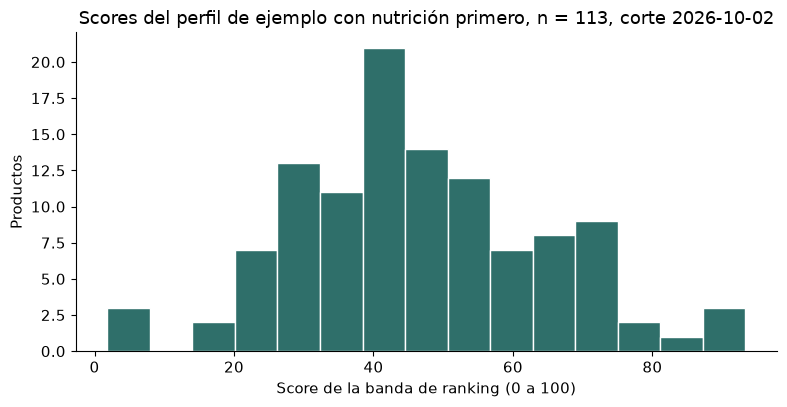

In [19]:
# Muestra la dispersión de los scores de la banda de ranking de este perfil.
# No es una probabilidad de compra.

fig, ax = plt.subplots()
ax.hist(ranking_a["score"].dropna(), bins=15, color="#2f6f6a", edgecolor="white")
ax.set_xlabel("Score de la banda de ranking (0 a 100)")
ax.set_ylabel("Productos")
ax.set_title("Scores del perfil de ejemplo con nutrición primero, n = 113, corte 2026-10-02")
plt.tight_layout()
plt.show()


El histograma muestra la dispersión de los 113 scores de esa banda. No es una distribución de probabilidad de compra. Sirve para ver que el orden no concentra a todos los productos en el mismo valor.


## 11. Limitaciones

En el corte del 2 de octubre de 2026:

- 12 834 productos no tienen precio de mercado. La ficha puede mostrar un monto de demostración, separado del ranking.
- 9 611 productos no permiten verificar el gluten porque no hay alérgenos ni trazas. El diseño responde con el estado no verificable, no con una imputación.
- 4 206 productos tienen calidad de información insuficiente. Esa medida no entra al score.
- El catálogo no observa clics, compras, favoritos ni ratings. Por eso no hay un target con el que entrenar un modelo supervisado.
- Las fuentes externas cubren de forma desigual nutrientes, NOVA, etiquetas y precios. El motor hereda esa cobertura.
- D1 y D3 se calculan al consultar. D2, los percentiles y la bandera de universo puntuable ya vienen en el archivo. Una cifra de disponibilidad del Parquet no sustituye a la banda que produce un perfil.
- 5 525 productos no tienen categoría de referencia, así que no tienen D1 por comparación. Siguen siendo consultables.

Estas limitaciones describen el dato y el alcance del motor. No son fallos de una fórmula que hubiera debido rellenar los huecos.


## 12. Conclusiones

1. El problema abordado es elegir entre alimentos empacados parecidos cuando la información nutricional, de procesamiento, de etiquetas, de alérgenos y de precio está dispersa y incompleta. NutriMatch ordena alternativas según el perfil declarado. No dicta un alimento saludable universal.

2. En el corte del 2 de octubre de 2026 el catálogo tiene 13 093 productos y 0 códigos duplicados. 5 864 (44,79 %) forman el universo puntuable. Hay 259 precios reales y 12 834 precios ausentes. La calidad de información es alta en 6 102, media en 1 511, baja en 1 274 e insuficiente en 4 206.

3. Esos huecos justifican las reglas ya construidas: no imputar precio, alérgeno, etiqueta ni grupo NOVA; comparar la nutrición dentro de una categoría de referencia; y separar de la banda de ranking a quien no tiene evidencia suficiente.

4. Las variables útiles son los percentiles con signo, D2, D3 en la consulta, los pesos del orden de prioridades y la cobertura. La calidad de información y el precio quedan fuera del score.

5. El score es el promedio ponderado de las dimensiones con dato. Con tres prioridades los pesos son 3/6, 2/6 y 1/6. Por debajo de una cobertura de 0,5 el score es nulo. La banda exclusiva es excluido, no verificable, información insuficiente o ranking.

6. La evaluación de este corte tiene cuatro piezas. El universo puntuable es 5 864 de 13 093, con la bandera idéntica a la regla. De 13 casos de oro, 12 pasan y uno falla por el contrato del nombre, no por el score. Spearman entre D1 y Nutri-Score es −0,475683 en 6 035 productos, con promedios de D1 que bajan de la letra A (59,68) a la E (41,57). Al invertir las prioridades, la banda de ranking pasa de 113 a 114 productos y el top 10 cambia. Dos ejecuciones iguales devuelven el mismo orden.

7. Permanecen la baja cobertura de precios y de alérgenos, la ausencia de un target de comportamiento y la diferencia entre el universo puntuable y lo que un perfil concreto puede ordenar.

8. La persona declara el perfil, consulta un producto y recibe un score, una banda y el detalle de las dimensiones. Con eso puede quedarse con el producto, mirar alternativas de la misma categoría o dejarlo fuera. El cálculo que sostiene esa pantalla es el de este cuaderno.

### Recomendaciones

El impacto que este cuaderno puede sostener está en la compra: la persona compara con la información disponible y con lo que declaró. No es una predicción de compra, porque el catálogo no observa qué producto se lleva.

1. Mantener el motor determinista mientras no existan compras, clics o favoritos observados. Usar el propio score como respuesta correcta volvería circular la evaluación.
2. No imputar alérgeno, grupo NOVA, etiqueta ni precio. Si más adelante llega una observación real, se puede incorporar con su fuente. Rellenar el hueco cambiaría el sentido de la comparación.
3. Seguir separando el precio real del monto de demostración, y dejar ambos fuera del orden. Ampliar la cobertura útil sería sumar precios observados por código de barras, no estimar los que faltan.
4. Conservar la banda no verificable cuando la dieta o la alergia no se pueden confirmar. Tratar ese silencio como apto ocultaría la falta de evidencia.
5. Al leer un resultado, no mezclar el catálogo, el universo puntuable y la banda de ranking de un perfil. Esos tres conjuntos no son la misma lista.
6. La acción que sí queda habilitada es de compra: conservar un producto, descartarlo, mirar alternativas, sustituirlo, revisar una restricción y cerrar el conjunto en el carrito. Eso no afirma que la persona vaya a comprar el primero de la lista.


## 13. Reproducibilidad

| Pieza | Valor |
| --- | --- |
| Dataset | `datos/procesados/dataset_referencia_20261002.parquet` |
| Corte | 2 de octubre de 2026 |
| Filas y columnas | 13 093 × 273 |
| SHA-256 | `a621d471a2f47aa09ba481408d95a7a808fe84bd2fa7205c56fa050e1c66045b` |
| Identificador de la fuente Open Food Facts | `off_csv_20260929` |
| Python del proyecto | 3.12, declarado en `.python-version` |
| Dependencias de análisis | pandas, pyarrow, matplotlib y el paquete `nutrimatch` |

Funciones reutilizadas, sin reescribir la fórmula: `Catalog.from_referencia_frame`, `calcular_subpuntaje_d1`, `calcular_d3`, `convertir_prioridades_a_pesos`, `_item_desde_fila`, `evaluar` y `calcular_parity_check`.

Desde la raíz del repositorio, con el entorno del proyecto ya instalado:

```text
pip install -e .
jupyter notebook notebooks/06_notebook_maestro_nutrimatch.ipynb
```

En Google Colab, sube `nutrimatch-colab.zip` a `/content` y ejecuta el cuaderno de arriba abajo. La primera celda de código descomprime ese archivo en `/content/nutrimatch`, instala el paquete y fija ahí el directorio de trabajo. En local, esa misma celda solo confirma la raíz y no reinstala nada. Este notebook no abre `off_mexico_20260919.parquet` ni otro corte. No descarga datos de una conexión externa.


Resultados que debe imprimir una ejecución completa:

- 13 093 filas, 273 columnas, 0 códigos duplicados y la huella de arriba.
- Calidad 6 102, 1 511, 1 274 y 4 206.
- Universo puntuable 5 864 (44,79 %), con 0 desajustes de la regla.
- Casos de oro: 13 presentes, 12 que pasan, y `5060323907641` que no pasa por `product_name`.
- Spearman −0,475683, n = 6 035.
- Banda de ranking del perfil de ejemplo: 113 con nutrición primero y 114 con procesamiento primero.
- Regla experimental del notebook previo: 665 elegibles.
- Dos pasadas con scores, bandas y orden iguales.

Si alguna de esas comprobaciones falla, la celda se detiene. La cifra obtenida no se reemplaza por la cifra esperada.
